In [361]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import regex
from sklearn.metrics import (accuracy_score,precision_score,classification_report,f1_score,confusion_matrix)

In [ ]:
df=pd.read_csv("diabetes_dirty_dataset.csv")
df

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,P0121,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,P0768,7,NaN,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,NaN,3.0,0
1011,P0746,2,131,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0
1012,P0071,4,144,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1
1013,P0608,0,79,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0


In [363]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   object 
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    object 
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek        933 non-null    float64
 14  Outcome 

In [364]:
df["Outcome"]=(df["Outcome"].str.replace(r"[^0-9.]","",regex=True).replace("",np.nan))
df["Outcome"]=df["Outcome"].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   object 
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    object 
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek        933 non-null    float64
 14  Outcome 

In [365]:
df["Glucose"].unique()
df["Glucose"]=(df["Glucose"].str.replace(r"[^0-9.]","",regex=True).replace("",np.nan))
df["Glucose"]=df["Glucose"].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   object 
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    float64
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek        933 non-null    float64
 14  Outcome 

In [366]:
def outliers_remover(df,columns):
    for i in columns:
        q1=df[i].quantile(0.25)
        q2=df[i].quantile(0.5)
        q3=df[i].quantile(0.75)
        iqr=(q3-q1)
        lb=q1-1.5*iqr
        ub=q3+1.5*iqr
        df=df[(df[i]>lb)&(df[i]<ub)]
    return df



In [367]:
df.isnull().sum()

PatientID                    0
Pregnancies                  0
Glucose                     80
BloodPressure                0
SkinThickness               80
Insulin                     78
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                     13
dtype: int64

In [368]:
df.skew(numeric_only=True)

Pregnancies                 0.452438
Glucose                     4.028416
BloodPressure               4.114101
SkinThickness              -1.022930
Insulin                     9.919267
BMI                         2.717210
DiabetesPedigreeFunction    0.875059
Age                         3.857598
Cholesterol                -0.007620
SodiumLevel                 0.184425
HeartRate                  -5.066095
VitaminD                    0.023040
ExerciseHrsPerWeek         -0.012959
Outcome                     0.619345
dtype: float64

PatientID                    0
Pregnancies                  0
Glucose                     80
BloodPressure                0
SkinThickness               80
Insulin                     78
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                     13
dtype: int64


<Axes: ylabel='SkinThickness'>

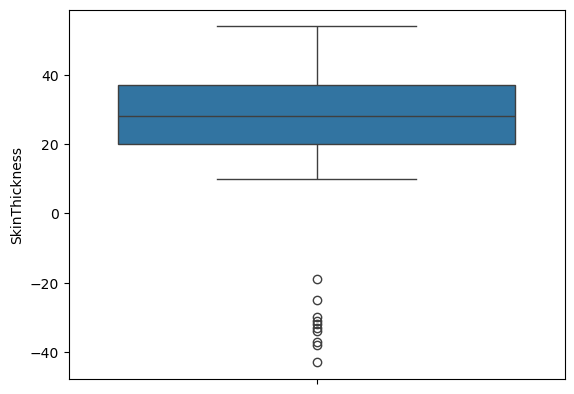

In [369]:
print(df.isnull().sum())
df["Glucose"]=df["Glucose"].fillna(df["Glucose"].median())
sns.boxplot(df["SkinThickness"])

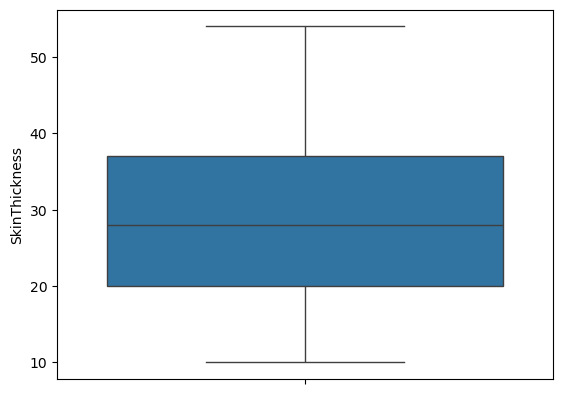

In [370]:
df["SkinThickness"]=abs(df["SkinThickness"])
sns.boxplot(df["SkinThickness"])
df["SkinThickness"]=df["SkinThickness"].fillna(df["SkinThickness"].median())

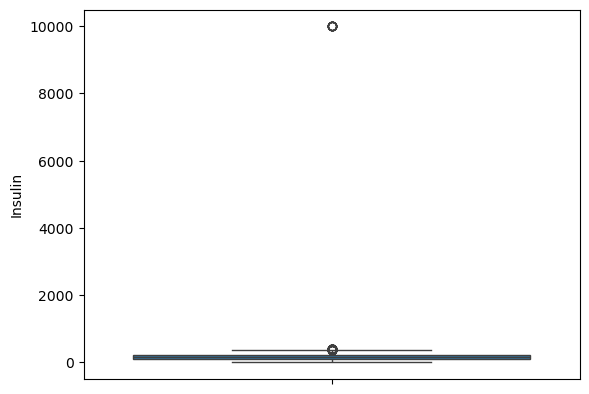

In [371]:
sns.boxplot(df["Insulin"])
df=outliers_remover(df,["Insulin"])

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_40770/590853861.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



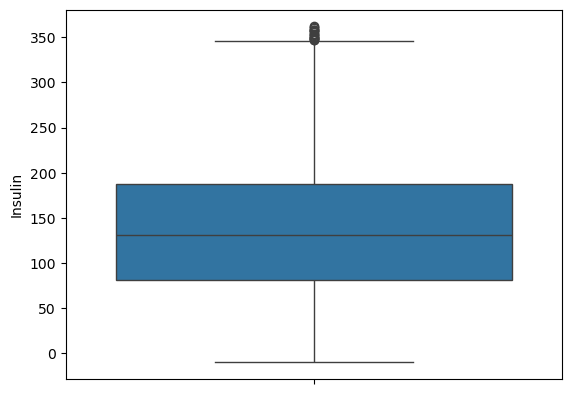

In [372]:
sns.boxplot(df["Insulin"])
df["Insulin"].skew()
df["Insulin"]=df["Insulin"].fillna(df["Insulin"].median())

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_40770/1155661350.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



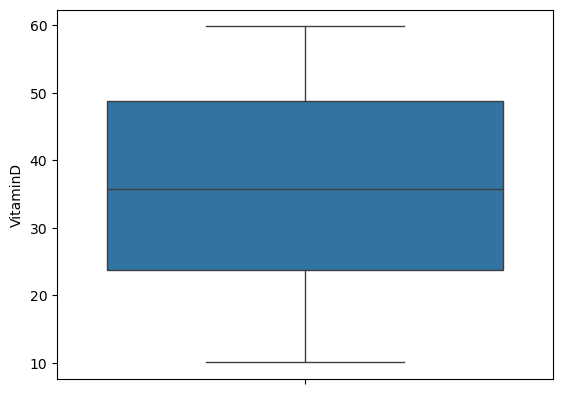

In [373]:
df["VitaminD"].unique()
sns.boxplot(df["VitaminD"])
df["VitaminD"].skew()
df["VitaminD"]=df["VitaminD"].fillna(df["VitaminD"].mean())

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_40770/2351619481.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



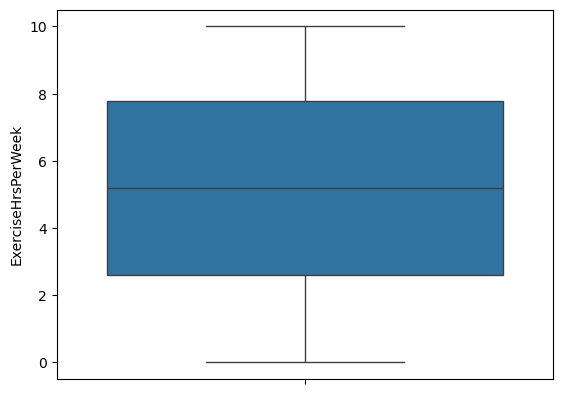

In [374]:
df["ExerciseHrsPerWeek"].unique()
df["ExerciseHrsPerWeek"].skew()
sns.boxplot(df["ExerciseHrsPerWeek"])
df["ExerciseHrsPerWeek"]=df["ExerciseHrsPerWeek"].fillna(df["ExerciseHrsPerWeek"].mean())

In [375]:
df["Outcome"]=df["Outcome"].fillna(df["Outcome"].median())

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_40770/3648753146.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [376]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 886 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 886 non-null    object 
 1   Pregnancies               886 non-null    int64  
 2   Glucose                   886 non-null    float64
 3   BloodPressure             886 non-null    int64  
 4   SkinThickness             886 non-null    float64
 5   Insulin                   886 non-null    float64
 6   BMI                       886 non-null    float64
 7   DiabetesPedigreeFunction  886 non-null    float64
 8   Age                       886 non-null    float64
 9   Cholesterol               886 non-null    int64  
 10  SodiumLevel               886 non-null    float64
 11  HeartRate                 886 non-null    int64  
 12  VitaminD                  886 non-null    float64
 13  ExerciseHrsPerWeek        886 non-null    float64
 14  Outcome       

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_40770/3354791766.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



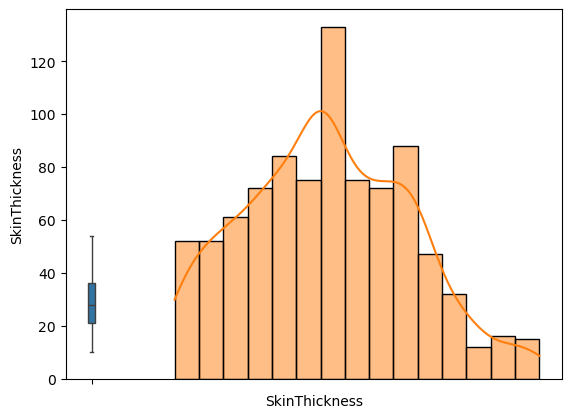

In [377]:
sns.boxplot(df["SkinThickness"])
df["SkinThickness"].skew()
sns.histplot(df["SkinThickness"],kde=True)
df["SkinThickness"]=df["SkinThickness"].fillna(df["SkinThickness"].median())

In [380]:
# df["Glucose"]=(df["Glucose"].str.replace(r"[^0-9.]","",regex=True).replace("",np.nan))
df["Glucose"]=df["Glucose"].astype(float)
df["Glucose"].isna().sum()
df["Glucose"]=df["Glucose"].fillna(df["Glucose"].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 886 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 886 non-null    object 
 1   Pregnancies               886 non-null    int64  
 2   Glucose                   886 non-null    float64
 3   BloodPressure             886 non-null    int64  
 4   SkinThickness             886 non-null    float64
 5   Insulin                   886 non-null    float64
 6   BMI                       886 non-null    float64
 7   DiabetesPedigreeFunction  886 non-null    float64
 8   Age                       886 non-null    float64
 9   Cholesterol               886 non-null    int64  
 10  SodiumLevel               886 non-null    float64
 11  HeartRate                 886 non-null    int64  
 12  VitaminD                  886 non-null    float64
 13  ExerciseHrsPerWeek        886 non-null    float64
 14  Outcome       

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_40770/1534085087.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_40770/1534085087.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [381]:
##logitic regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
model=LogisticRegression()
scaler=StandardScaler()
df
X=df.drop(columns=["Outcome","PatientID"])
y=df["Outcome"]
X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 886 entries, 0 to 1014
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               886 non-null    int64  
 1   Glucose                   886 non-null    float64
 2   BloodPressure             886 non-null    int64  
 3   SkinThickness             886 non-null    float64
 4   Insulin                   886 non-null    float64
 5   BMI                       886 non-null    float64
 6   DiabetesPedigreeFunction  886 non-null    float64
 7   Age                       886 non-null    float64
 8   Cholesterol               886 non-null    int64  
 9   SodiumLevel               886 non-null    float64
 10  HeartRate                 886 non-null    int64  
 11  VitaminD                  886 non-null    float64
 12  ExerciseHrsPerWeek        886 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 96.9 KB


<Axes: xlabel='Outcome'>

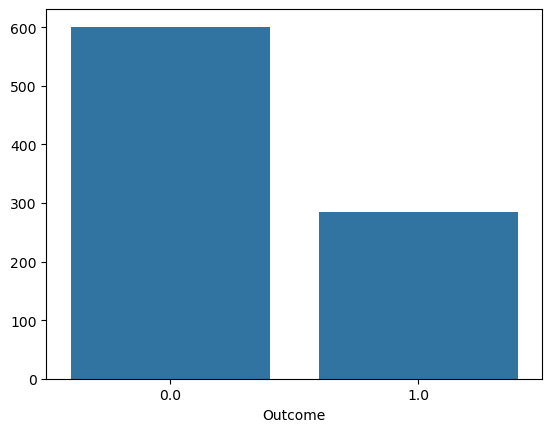

In [318]:
count=df["Outcome"].value_counts()
sns.barplot(x=count.index,y=count.values)

In [382]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Cholesterol                 0
SodiumLevel                 0
HeartRate                   0
VitaminD                    0
ExerciseHrsPerWeek          0
dtype: int64

In [320]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)#beacuse x and y are not equal in number
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [321]:
y_pred=model.predict(X_test)
print("Accuracy score is:",accuracy_score(y_pred,y_test))
print("precison score is:",precision_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("f1 score is:",f1_score(y_test,y_pred))

Accuracy score is: 0.9414414414414415
precison score is: 0.9178082191780822
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96       148
         1.0       0.92      0.91      0.91        74

    accuracy                           0.94       222
   macro avg       0.94      0.93      0.93       222
weighted avg       0.94      0.94      0.94       222

f1 score is: 0.9115646258503401


[[142   7]
 [  6  67]]
(664, 13)


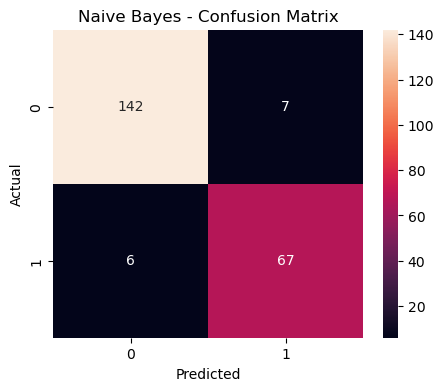

In [322]:
cm=confusion_matrix(y_pred,y_test)
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(
cm,
annot=True,
fmt='d',
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")
print(X_train.shape)

In [323]:
#so this is having some leanear data so in this case we use this so called Gaussian naive bayes
from sklearn.naive_bayes import GaussianNB
model1=GaussianNB()
model1.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [324]:
y_pred=model1.predict(X_test)
print("Accuracy score is:",accuracy_score(y_pred,y_test))
print("precison score is:",precision_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("f1 score is:",f1_score(y_test,y_pred))

Accuracy score is: 0.9369369369369369
precison score is: 0.9054054054054054
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95       148
         1.0       0.91      0.91      0.91        74

    accuracy                           0.94       222
   macro avg       0.93      0.93      0.93       222
weighted avg       0.94      0.94      0.94       222

f1 score is: 0.9054054054054054


[[141   7]
 [  7  67]]


Text(0.5, 1.0, 'Naive Bayes - Confusion Matrix')

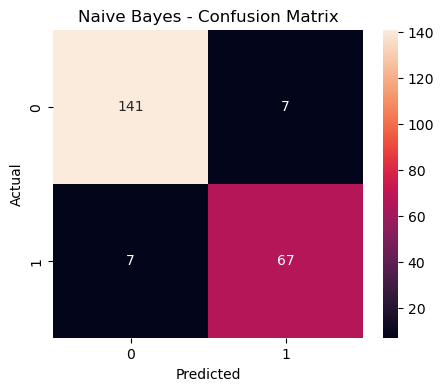

In [325]:
cm=confusion_matrix(y_pred,y_test)
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(
cm,
annot=True,
fmt='d',
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")

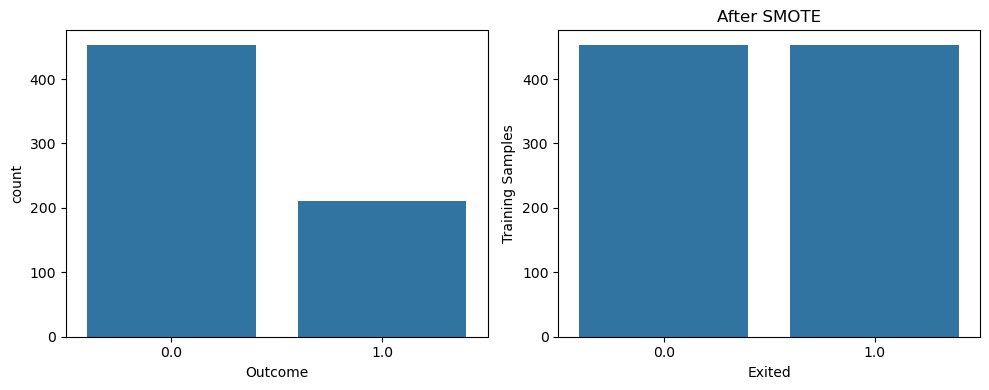

In [326]:
#this is without using smote after using smote
from imblearn.over_sampling import SMOTE
fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.countplot(x=y_train,ax=ax[0])
smote=SMOTE(random_state=42)
X_train_balanced, y_train_balanced= smote.fit_resample(X_train,y_train)
sns.countplot(x=y_train_balanced, ax=ax[1])
ax[1].set_title("After SMOTE")
ax[1].set_xlabel("Exited")
ax[1].set_ylabel("Training Samples")
plt.tight_layout()
plt.show()

In [327]:
model1.fit(X_train_balanced,y_train_balanced)

,priors,None
,var_smoothing,1e-09


In [328]:
y_pred=model1.predict(X_test)
print("Accuracy score is:",accuracy_score(y_pred,y_test))
print("precison score is:",precision_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("f1 score is:",f1_score(y_test,y_pred))
X_train_balanced.shape

Accuracy score is: 0.9504504504504504
precison score is: 0.9315068493150684
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       148
         1.0       0.93      0.92      0.93        74

    accuracy                           0.95       222
   macro avg       0.95      0.94      0.94       222
weighted avg       0.95      0.95      0.95       222

f1 score is: 0.9251700680272109


(906, 13)

[[143   6]
 [  5  68]]


Text(0.5, 1.0, 'Naive Bayes - Confusion Matrix')

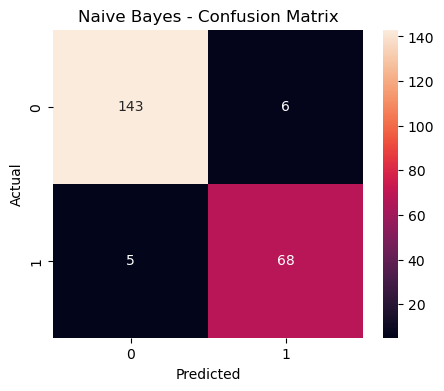

In [329]:
cm=confusion_matrix(y_pred,y_test)
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(
cm,
annot=True,
fmt='d',
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 886 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 886 non-null    object 
 1   Pregnancies               886 non-null    int64  
 2   Glucose                   886 non-null    float64
 3   BloodPressure             886 non-null    int64  
 4   SkinThickness             886 non-null    float64
 5   Insulin                   886 non-null    float64
 6   BMI                       886 non-null    float64
 7   DiabetesPedigreeFunction  886 non-null    float64
 8   Age                       886 non-null    float64
 9   Cholesterol               886 non-null    int64  
 10  SodiumLevel               886 non-null    float64
 11  HeartRate                 886 non-null    int64  
 12  VitaminD                  886 non-null    float64
 13  ExerciseHrsPerWeek        886 non-null    float64
 14  Outcome       

In [331]:
df

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120.0,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.800000,6.5,0.0
1,P0283,8,121.0,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.500000,1.2,1.0
3,P0121,2,115.0,0,28.0,52.0,27.3,1.015,37.0,155,143.5,90,27.700000,6.3,0.0
4,P0001,2,129.0,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.000000,6.8,0.0
5,P0943,2,197.0,88,29.0,170.0,47.0,2.107,58.0,217,135.3,75,32.100000,8.6,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,P0768,7,122.0,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,35.790394,3.0,0.0
1011,P0746,2,131.0,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.300000,7.6,0.0
1012,P0071,4,144.0,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.100000,3.6,1.0
1013,P0608,0,79.0,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.900000,9.0,0.0


In [332]:
import plotly.express as px
fig=px.scatter_3d(
    df,
    x="SkinThickness",
    y="Pregnancies",
    z="Cholesterol",
    color="Outcome",
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.show()

In [333]:
#now it is the time to usethis so called pca
df.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
Pregnancies,1.000000,0.193607,0.127213,0.155846,0.183311,0.190855,0.192463,0.049529,0.009979,0.046905,-0.009926,0.017076,0.013368,0.338252
Glucose,0.193607,1.000000,0.155310,0.203204,0.313313,0.259884,0.296238,0.099432,-0.032075,0.004954,-0.002878,0.013764,-0.017202,0.524383
BloodPressure,0.127213,0.155310,1.000000,0.140087,0.213607,0.132757,0.181735,0.067158,-0.037540,-0.001167,-0.053188,-0.046838,-0.016417,0.305222
SkinThickness,0.155846,0.203204,0.140087,1.000000,0.314004,0.211089,0.313485,0.105057,-0.077916,0.043476,0.007256,-0.026456,-0.041679,0.450531
Insulin,0.183311,0.313313,0.213607,0.314004,1.000000,0.337481,0.426217,0.074090,0.006668,0.016169,0.012216,-0.009455,-0.064428,0.607961
BMI,0.190855,0.259884,0.132757,0.211089,0.337481,1.000000,0.276066,0.156312,0.012697,-0.026723,-0.019894,-0.043056,-0.007323,0.463949
DiabetesPedigreeFunction,0.192463,0.296238,0.181735,0.313485,0.426217,0.276066,1.000000,0.108748,0.007637,0.025535,-0.047145,-0.033143,-0.048827,0.586878
Age,0.049529,0.099432,0.067158,0.105057,0.074090,0.156312,0.108748,1.000000,0.013584,-0.015518,-0.012778,0.018713,0.039162,0.217433
Cholesterol,0.009979,-0.032075,-0.037540,-0.077916,0.006668,0.012697,0.007637,0.013584,1.000000,-0.093748,-0.063177,-0.006536,-0.059125,0.027186
SodiumLevel,0.046905,0.004954,-0.001167,0.043476,0.016169,-0.026723,0.025535,-0.015518,-0.093748,1.000000,0.020430,0.001822,-0.022614,0.007043


In [334]:
df.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
Pregnancies,1.000000,0.193607,0.127213,0.155846,0.183311,0.190855,0.192463,0.049529,0.009979,0.046905,-0.009926,0.017076,0.013368,0.338252
Glucose,0.193607,1.000000,0.155310,0.203204,0.313313,0.259884,0.296238,0.099432,-0.032075,0.004954,-0.002878,0.013764,-0.017202,0.524383
BloodPressure,0.127213,0.155310,1.000000,0.140087,0.213607,0.132757,0.181735,0.067158,-0.037540,-0.001167,-0.053188,-0.046838,-0.016417,0.305222
SkinThickness,0.155846,0.203204,0.140087,1.000000,0.314004,0.211089,0.313485,0.105057,-0.077916,0.043476,0.007256,-0.026456,-0.041679,0.450531
Insulin,0.183311,0.313313,0.213607,0.314004,1.000000,0.337481,0.426217,0.074090,0.006668,0.016169,0.012216,-0.009455,-0.064428,0.607961
BMI,0.190855,0.259884,0.132757,0.211089,0.337481,1.000000,0.276066,0.156312,0.012697,-0.026723,-0.019894,-0.043056,-0.007323,0.463949
DiabetesPedigreeFunction,0.192463,0.296238,0.181735,0.313485,0.426217,0.276066,1.000000,0.108748,0.007637,0.025535,-0.047145,-0.033143,-0.048827,0.586878
Age,0.049529,0.099432,0.067158,0.105057,0.074090,0.156312,0.108748,1.000000,0.013584,-0.015518,-0.012778,0.018713,0.039162,0.217433
Cholesterol,0.009979,-0.032075,-0.037540,-0.077916,0.006668,0.012697,0.007637,0.013584,1.000000,-0.093748,-0.063177,-0.006536,-0.059125,0.027186
SodiumLevel,0.046905,0.004954,-0.001167,0.043476,0.016169,-0.026723,0.025535,-0.015518,-0.093748,1.000000,0.020430,0.001822,-0.022614,0.007043


In [335]:
import ipywidgets as widgets
import pandas as pd
import plotly.express as px
from IPython.display import display

# Columns available to select
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Cholesterol",
    "SodiumLevel",
    "HeartRate",
    "VitaminD",
    "ExerciseHrsPerWeek",
]

# Dropdown controls
x_dropdown = widgets.Dropdown(options=features, value="Glucose", description="X Axis:")
y_dropdown = widgets.Dropdown(
    options=["None"] + features, value="Insulin", description="Y Axis:"
)
z_dropdown = widgets.Dropdown(
    options=["None"] + features, value="BMI", description="Z Axis:"
)
color_dropdown = widgets.Dropdown(
    options=["Outcome"] + features, value="Outcome", description="Color By:"
)

# Output container for the figure
plot_output = widgets.Output()


def update_plot(change=None):
    x = x_dropdown.value
    y = y_dropdown.value
    z = z_dropdown.value
    color_by = color_dropdown.value

    with plot_output:
        plot_output.clear_output(wait=True)

        # 3D Plot
        if y != "None" and z != "None":
            fig = px.scatter_3d(
                df,
                x=x,
                y=y,
                z=z,
                color=color_by,
                color_discrete_sequence=px.colors.qualitative.Set1,
                title=f"3D Scatter: {x} vs {y} vs {z}",
            )
        # 2D Plot
        elif y != "None" and z == "None":
            fig = px.scatter(
                df,
                x=x,
                y=y,
                color=color_by,
                color_discrete_sequence=px.colors.qualitative.Set1,
                title=f"2D Scatter: {x} vs {y}",
            )
        # 1D Histogram
        else:
            fig = px.histogram(
                df,
                x=x,
                color=color_by,
                barmode="overlay",
                title=f"Distribution of {x}",
            )

        fig.update_layout(height=600, margin=dict(l=20, r=20, t=40, b=20))
        fig.show()


# Bind change events to dropdowns
x_dropdown.observe(update_plot, names="value")
y_dropdown.observe(update_plot, names="value")
z_dropdown.observe(update_plot, names="value")
color_dropdown.observe(update_plot, names="value")

# Render UI layout
controls = widgets.VBox(
    [
        widgets.HBox([x_dropdown, y_dropdown]),
        widgets.HBox([z_dropdown, color_dropdown]),
    ]
)

display(controls)
display(plot_output)

# Render initial plot
update_plot()

Output()

In [336]:
import ipywidgets as widgets
import pandas as pd
import plotly.express as px
from IPython.display import display

# Available numerical columns from your dataframe
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Cholesterol",
    "SodiumLevel",
    "HeartRate",
    "VitaminD",
    "ExerciseHrsPerWeek",
]

# Dropdown controls for 2D plot
x_dropdown = widgets.Dropdown(options=features, value="Glucose", description="X Column:")
y_dropdown = widgets.Dropdown(options=features, value="Insulin", description="Y Column:")
color_dropdown = widgets.Dropdown(
    options=["Outcome"] + features, value="Outcome", description="Color By:"
)

# Container for graph output
plot_output = widgets.Output()


def update_2d_plot(change=None):
    x_col = x_dropdown.value
    y_col = y_dropdown.value
    color_col = color_dropdown.value

    with plot_output:
        plot_output.clear_output(wait=True)

        # Generate 2D Scatter Plot
        fig = px.scatter(
            df,
            x=x_col,
            y=y_col,
            color=color_col,
            color_discrete_sequence=px.colors.qualitative.Set1,
            title=f"2D Plot: {x_col} vs {y_col}",
            hover_data=df.columns,  # Shows all row details when hovering over points
        )

        fig.update_layout(height=550, margin=dict(l=20, r=20, t=40, b=20))
        fig.show()


# Re-render plot whenever a dropdown selection changes
x_dropdown.observe(update_2d_plot, names="value")
y_dropdown.observe(update_2d_plot, names="value")
color_dropdown.observe(update_2d_plot, names="value")

# Display controls and graph layout
controls = widgets.VBox(
    [
        widgets.HBox([x_dropdown, y_dropdown]),
        widgets.HBox([color_dropdown]),
    ]
)

display(controls)
display(plot_output)

# Display initial plot
update_2d_plot()

Output()

In [ ]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Cholesterol                 0
SodiumLevel                 0
HeartRate                   0
VitaminD                    0
ExerciseHrsPerWeek          0
dtype: int64

In [386]:
#using pca
from sklearn.decomposition import PCA
pca=PCA()
X_scaled=scaler.fit_transform(X)
X_pca=pca.fit_transform(X_scaled)
print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (886, 13)
PCA shape: (886, 13)


In [410]:
explained_variance=pca.explained_variance_ratio_
# np.cumsum(pca.explained_variance_ratio_)
explained_variance

array([0.19072942, 0.08899848, 0.08272025, 0.07882241, 0.07571897,
       0.07259154, 0.07123985, 0.06683676, 0.06306127, 0.06072541,
       0.05581916, 0.05043859, 0.04229787])

In [411]:
variance_ratio = X_scaled.var() / X_scaled.var().sum()
variance_ratio

np.float64(1.0)

In [412]:
explained_variance_df= pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Explained Variance (%)": explained_variance * 100
})
explained_variance_df

,Principal Component,Explained Variance Ratio,Explained Variance (%)
0,1,0.190729,19.072942
1,2,0.088998,8.899848
2,3,0.082720,8.272025
3,4,0.078822,7.882241
4,5,0.075719,7.571897
5,6,0.072592,7.259154
6,7,0.071240,7.123985
7,8,0.066837,6.683676
8,9,0.063061,6.306127
9,10,0.060725,6.072541


In [415]:
cumulative_variance=np.cumsum(pca.explained_variance_ratio_)
cumulative_variance
cumulative_variance_df= pd.DataFrame({
"Number of Components": range(1, len(cumulative_variance) + 1),
"Cumulative Explained Variance": cumulative_variance,
"Cumulative Explained Variance (%)": cumulative_variance * 100
})
cumulative_variance_df

,Number of Components,Cumulative Explained Variance,Cumulative Explained Variance (%)
0,1,0.190729,19.072942
1,2,0.279728,27.972790
2,3,0.362448,36.244815
3,4,0.441271,44.127056
4,5,0.516990,51.698953
5,6,0.589581,58.958107
6,7,0.660821,66.082092
7,8,0.727658,72.765768
8,9,0.790719,79.071896
9,10,0.851444,85.144437


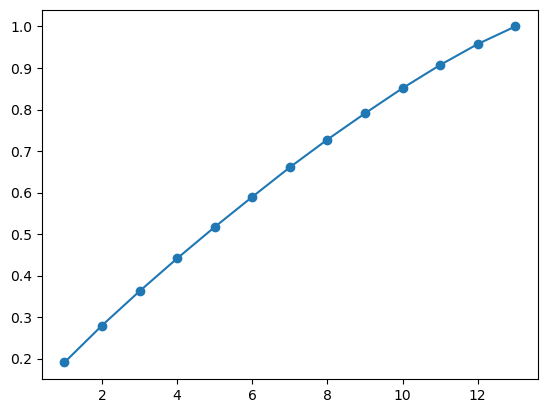

In [421]:
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker='o')

In [436]:
n_components_95=np.argmax(cumulative_variance>=0.95)+1
cumulative_variance[n_components_95-1]*100

np.float64(95.77021260519672)

In [438]:
pca_reduced=PCA(n_components=n_components_95)
X_reduced=pca_reduced.fit_transform(X_scaled)
print("Original data shape:", X_scaled.shape)
print("Reduced data shape:", X_reduced.shape)

Original data shape: (886, 13)
Reduced data shape: (886, 12)


In [442]:
pca_12d_df=pd.DataFrame(
    X_reduced,
    columns=range(1,13)
)

In [443]:
pca_12d_df

,1,2,3,4,5,6,7,8,9,10,11,12
0,0.043356,-1.005487,-0.233313,-1.627290,0.661878,0.391617,-0.261048,-0.528013,0.101198,0.446333,-0.135018,-0.568879
1,0.888636,0.679439,-0.054098,1.212161,-0.297809,-0.042304,-0.239565,1.816257,0.827847,0.774355,0.425241,-0.794897
2,-1.564204,-2.083306,-0.186507,-0.027347,0.483384,1.024998,1.111940,-2.250382,0.719299,-0.255135,-0.467113,0.529310
3,-1.384818,0.598667,0.575250,0.668465,-0.275796,-1.302451,-0.997550,-0.185144,-0.623166,-0.507761,-0.226014,0.043590
4,2.187013,1.248421,1.734142,-0.679499,0.667544,-0.080006,-0.468905,-0.795814,-0.752202,-0.895449,-0.620583,0.505810
...,...,...,...,...,...,...,...,...,...,...,...,...
881,-0.048985,0.127987,-0.762729,0.762189,-0.642088,0.237459,1.635387,-0.062458,0.585959,0.441315,-0.161343,-0.384543
882,-1.641522,-1.440286,1.187560,1.282622,0.562973,-0.190044,-0.112859,-2.196940,0.582106,-1.233999,-0.069276,1.427281
883,1.137238,-1.499688,-1.359418,-0.770399,1.430740,-0.075528,-0.234030,-0.608140,0.531211,-0.308279,-0.120072,0.586553
884,-0.902825,2.047820,5.972488,-0.111141,-1.949983,5.786099,-0.065667,1.239207,-0.061114,1.011298,-0.924634,0.400176


So if your original data is:
Row     X data              Target
0       student A            1
1       student B            0
2       student C            1
3       student D            0
After PCA:
Row     PC1      PC2
0       ...      ...
1       ...      ...
2       ...      ...
3       ...      ...
Row 0 is still the same student A, row 1 is still student B, etc.


In [445]:
pca_12d_df["Outcome"]=y.values
pca_12d_df

,1,2,3,4,5,6,7,8,9,10,11,12,Outcome
0,0.043356,-1.005487,-0.233313,-1.627290,0.661878,0.391617,-0.261048,-0.528013,0.101198,0.446333,-0.135018,-0.568879,0.0
1,0.888636,0.679439,-0.054098,1.212161,-0.297809,-0.042304,-0.239565,1.816257,0.827847,0.774355,0.425241,-0.794897,1.0
2,-1.564204,-2.083306,-0.186507,-0.027347,0.483384,1.024998,1.111940,-2.250382,0.719299,-0.255135,-0.467113,0.529310,0.0
3,-1.384818,0.598667,0.575250,0.668465,-0.275796,-1.302451,-0.997550,-0.185144,-0.623166,-0.507761,-0.226014,0.043590,0.0
4,2.187013,1.248421,1.734142,-0.679499,0.667544,-0.080006,-0.468905,-0.795814,-0.752202,-0.895449,-0.620583,0.505810,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,-0.048985,0.127987,-0.762729,0.762189,-0.642088,0.237459,1.635387,-0.062458,0.585959,0.441315,-0.161343,-0.384543,0.0
882,-1.641522,-1.440286,1.187560,1.282622,0.562973,-0.190044,-0.112859,-2.196940,0.582106,-1.233999,-0.069276,1.427281,0.0
883,1.137238,-1.499688,-1.359418,-0.770399,1.430740,-0.075528,-0.234030,-0.608140,0.531211,-0.308279,-0.120072,0.586553,1.0
884,-0.902825,2.047820,5.972488,-0.111141,-1.949983,5.786099,-0.065667,1.239207,-0.061114,1.011298,-0.924634,0.400176,0.0


<Axes: xlabel='4', ylabel='2'>

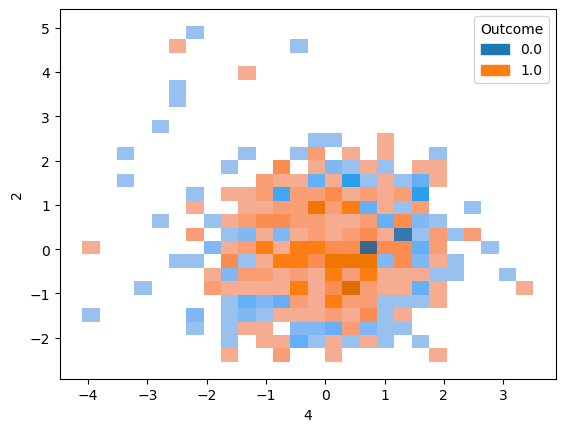

In [450]:
sns.histplot(x=pca_12d_df[4],y=pca_12d_df[2],data=df,hue="Outcome")

In [461]:
import plotly.express as px
fig=px.scatter_3d(
    pca_12d_df,
    x=pca_12d_df[7],
    y=pca_12d_df[5],
    z=pca_12d_df[4],
    color="Outcome",
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.show()

<Axes: xlabel='Outcome', ylabel='count'>

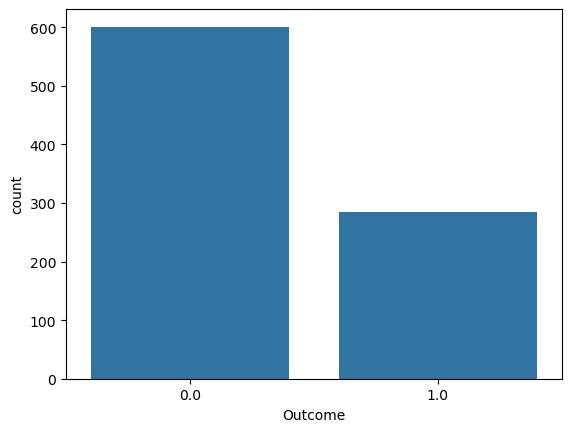

In [463]:
#now we can start our model training 
sns.countplot(x=pca_12d_df["Outcome"])

In [468]:
X=pca_12d_df.drop(columns=["Outcome"])
y=pca_12d_df["Outcome"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

<h1>Without using somte</h1>

In [471]:
#before using some we traing our model once
model1.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [472]:
y_pred=model1.predict(X_test)
print("Accuracy score is:",accuracy_score(y_pred,y_test))
print("precison score is:",precision_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("f1 score is:",f1_score(y_test,y_pred))
X_train_balanced.shape

Accuracy score is: 0.9325842696629213
precison score is: 0.8888888888888888
              precision    recall  f1-score   support

         0.0       0.96      0.94      0.95       117
         1.0       0.89      0.92      0.90        61

    accuracy                           0.93       178
   macro avg       0.92      0.93      0.93       178
weighted avg       0.93      0.93      0.93       178

f1 score is: 0.9032258064516129


(906, 13)

<h1>With using somte</h1>

In [474]:
smote=SMOTE(random_state=42)
X_ps_train,y_ps_train=smote.fit_resample(X_train,y_train)

<Axes: xlabel='Outcome', ylabel='count'>

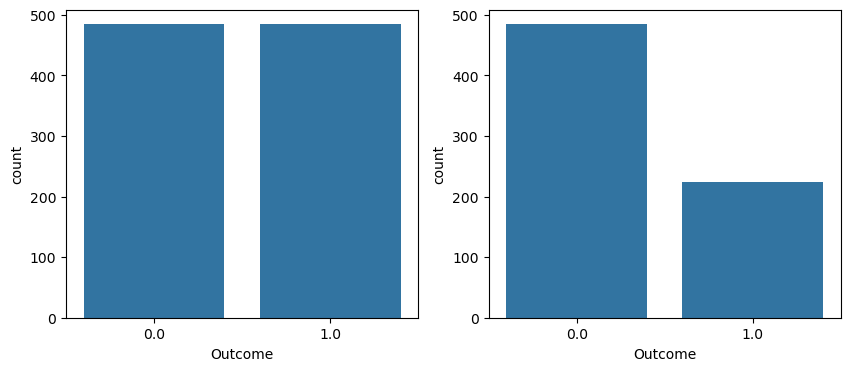

In [479]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
sns.countplot(x=y_ps_train,ax=axes[0])
sns.countplot(x=y_train,ax=axes[1])

In [480]:
model1.fit(X_ps_train,y_ps_train)


,priors,None
,var_smoothing,1e-09


In [481]:
y_pred=model1.predict(X_test)
print("Accuracy score is:",accuracy_score(y_pred,y_test))
print("precison score is:",precision_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("f1 score is:",f1_score(y_test,y_pred))
X_train_balanced.shape

Accuracy score is: 0.949438202247191
precison score is: 0.90625
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       117
         1.0       0.91      0.95      0.93        61

    accuracy                           0.95       178
   macro avg       0.94      0.95      0.94       178
weighted avg       0.95      0.95      0.95       178

f1 score is: 0.928


(906, 13)

<h2>Now we are doing Knearest nighbour</h1>

In [484]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
kmeans=KNeighborsClassifier()
param_grid= {
'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
'weights': ['uniform', 'distance'],
'metric': ['euclidean', 'manhattan']
}
grid=GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
)
grid.fit(X_ps_train,y_ps_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [495]:
grid.best_params_
model_grid=grid.best_estimator_
y_ps_pred=model_grid.predict(X_test)


In [496]:
print("Accuracy score is:",accuracy_score(y_ps_pred,y_pred))
print("precison score is:",precision_score(y_ps_pred,y_pred))
print(classification_report(y_ps_pred,y_pred))
print("f1 score is:",f1_score(y_ps_pred,y_pred))
X_train_balanced.shape

Accuracy score is: 0.9438202247191011
precison score is: 0.875
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.96       120
         1.0       0.88      0.97      0.92        58

    accuracy                           0.94       178
   macro avg       0.93      0.95      0.94       178
weighted avg       0.95      0.94      0.94       178

f1 score is: 0.9180327868852459


(906, 13)

<Axes: >

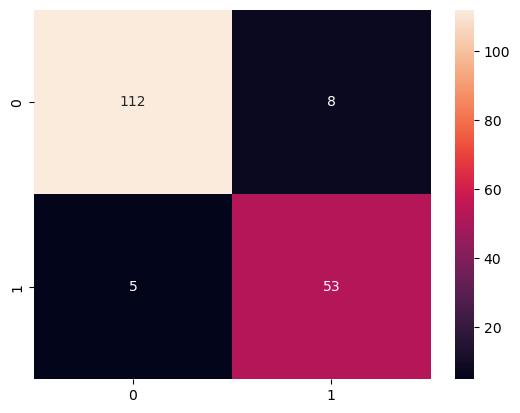

In [498]:
sns.heatmap(confusion_matrix(y_ps_pred,y_test),annot=True,fmt='d')

In [517]:
from sklearn.svm import SVC
svm=SVC()
pipe=Pipeline([
    ("model",svm)
])
params={
    "model__kernel":["rbf","linear","poly"],
    "model__C":[0.1,1,10,100],
    "model__degree":[2,3,4],
    'model__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}
grid=GridSearchCV(
    estimator=pipe,
    param_grid=params,
    cv=5,
    scoring="f1"
)


In [518]:
grid.fit(X_ps_train,y_ps_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.1, 1, ...], 'model__degree': [2, 3, ...], 'model__gamma': ['scale', 'auto', ...], 'model__kernel': ['rbf', 'linear', ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [520]:
grid.best_params_

{'model__C': 1,
 'model__degree': 3,
 'model__gamma': 'scale',
 'model__kernel': 'poly'}

In [525]:
model_grid=grid.best_estimator_
y_ps_pred=model_grid.predict(X_test)
print("Accuracy score is:",accuracy_score(y_ps_pred,y_pred))
print("precison score is:",precision_score(y_ps_pred,y_pred))
print(classification_report(y_ps_pred,y_pred))
print("f1 score is:",f1_score(y_ps_pred,y_pred))
X_train_balanced.shape

Accuracy score is: 0.9775280898876404
precison score is: 0.96875
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       114
         1.0       0.97      0.97      0.97        64

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178

f1 score is: 0.96875


(906, 13)

<Axes: >

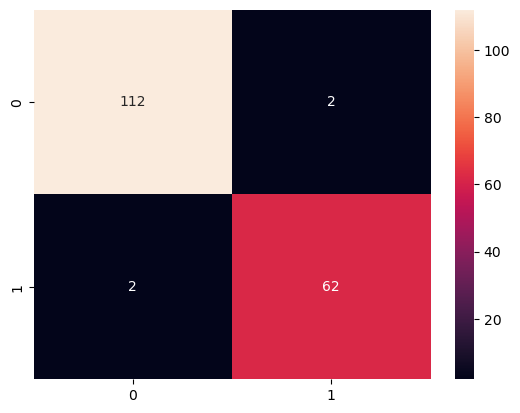

In [524]:
sns.heatmap(confusion_matrix(y_ps_pred,y_pred),annot=True,fmt='d')